# Supply Chain Delay Root Cause Analysis

## Project Overview
This project analyses 180,519 orders from the DataCo Supply Chain dataset to identify 
the root causes of late deliveries across shipping modes, markets, regions, departments, 
and time periods. The goal is to surface actionable insights that operations and logistics 
teams can use to reduce delivery failures.

**Dataset:** DataCo Smart Supply Chain Dataset (Kaggle)  
**Tools:** Python, Pandas, Matplotlib, Seaborn  
**Key Finding:** 55% of all orders are delivered late, with Standard Class shipping 
and the LATAM market being the biggest contributors.

In [123]:
# Import Libraries
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import datetime 

In [124]:
# Load Dataset
supply = pd.read_csv("C:/Users/USER/Documents/DataCoSupplyChainDataset.csv",encoding='latin1')
print(supply.head())

       Type  Days for shipping (real)  Days for shipment (scheduled)  \
0     DEBIT                         3                              4   
1  TRANSFER                         5                              4   
2      CASH                         4                              4   
3     DEBIT                         3                              4   
4   PAYMENT                         2                              4   

   Benefit per order  Sales per customer   Delivery Status  \
0          91.250000          314.640015  Advance shipping   
1        -249.089996          311.359985     Late delivery   
2        -247.779999          309.720001  Shipping on time   
3          22.860001          304.809998  Advance shipping   
4         134.210007          298.250000  Advance shipping   

   Late_delivery_risk  Category Id   Category Name Customer City  ...  \
0                   0           73  Sporting Goods        Caguas  ...   
1                   1           73  Sporting Goo

## Data Cleaning

Steps taken:
- Removed duplicate rows
- Checked null values across all columns
- Dropped irrelevant columns: customer PII, coordinates, product image and description
- Dropped Order Zipcode (86% null, no analytical value)
- Converted date columns to datetime format
- Created new column: **delay gap** (actual shipping days minus scheduled shipping days)

In [125]:
supply.drop_duplicates(inplace=True)

In [126]:
supply.isna().sum()

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


In [127]:
supply.drop(columns=["Customer Email","Customer Password","Customer Fname","Customer Lname","Customer Street","Customer Zipcode","Product Image",
                     "Product Description","Latitude","Longitude", "Order Zipcode"], inplace=True)

In [128]:
supply.isna().sum()

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Id                      0
Category Name                    0
Customer City                    0
Customer Country                 0
Customer Id                      0
Customer Segment                 0
Customer State                   0
Department Id                    0
Department Name                  0
Market                           0
Order City                       0
Order Country                    0
Order Customer Id                0
order date (DateOrders)          0
Order Id                         0
Order Item Cardprod Id           0
Order Item Discount              0
Order Item Discount Rate         0
Order Item Id                    0
Order Item Product Price         0
Order Item Profit Ratio          0
Order Item Quantity 

In [129]:
supply.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 42 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Id                    180519 non-null  int64  
 12  Customer Segment              

In [130]:
supply["shipping date (DateOrders)"]=pd.to_datetime(supply["shipping date (DateOrders)"])
supply["order date (DateOrders)"]=pd.to_datetime(supply["order date (DateOrders)"])

In [131]:
supply.shape

(180519, 42)

In [132]:
supply.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Department Id,Order Customer Id,order date (DateOrders),...,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Card Id,Product Category Id,Product Price,Product Status,shipping date (DateOrders)
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519,...,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.0,180519
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,5.443460,6691.379495,2016-06-12 17:47:04.669868544,...,0.120647,2.127638,203.772096,183.107609,21.974989,692.509764,31.851451,141.232550,0.0,2016-06-16 05:45:23.202433024
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,2.000000,1.000000,2015-01-01 00:00:00,...,-2.750000,1.000000,9.990000,7.490000,-4274.979980,19.000000,2.000000,9.990000,0.0,2015-01-03 00:00:00
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,4.000000,3258.500000,2015-09-21 13:49:00,...,0.080000,1.000000,119.980003,104.379997,7.000000,403.000000,18.000000,50.000000,0.0,2015-09-25 06:59:00
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,5.000000,6457.000000,2016-06-11 13:06:00,...,0.270000,1.000000,199.919998,163.990005,31.520000,627.000000,29.000000,59.990002,0.0,2016-06-15 08:32:00
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,7.000000,9779.000000,2017-03-01 08:42:00,...,0.360000,3.000000,299.950012,247.399994,64.800003,1004.000000,45.000000,199.990005,0.0,2017-03-04 21:29:00
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,12.000000,20757.000000,2018-01-31 23:38:00,...,0.500000,5.000000,1999.989990,1939.989990,911.799988,1363.000000,76.000000,1999.989990,0.0,2018-02-06 22:14:00
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,1.629246,4162.918106,NaN,...,0.466796,1.453451,132.273077,120.043670,104.433526,336.446807,15.640064,139.732492,0.0,NaN


In [133]:
supply["Delivery Status"].value_counts()

Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

In [134]:
late_deliveries= supply["Delivery Status"].value_counts(normalize=True)*100
print(round(late_deliveries.head(1)),3)

Delivery Status
Late delivery    55.0
Name: proportion, dtype: float64 3


In [135]:
late_deliveries= supply["Delivery Status"].value_counts(normalize=True)*100
print(round(late_deliveries[2:4]),3)

Delivery Status
Shipping on time     18.0
Shipping canceled     4.0
Name: proportion, dtype: float64 3


In [136]:
supply["delay gap"] = supply["Days for shipping (real)"]-supply["Days for shipment (scheduled)"]


In [137]:
supply["delay gap"].dtypes

dtype('int64')

In [138]:
average_delay_gap=supply["delay gap"].mean().round(2)
print(average_delay_gap)

0.57


In [139]:
most_used_shipping_mode = supply["Shipping Mode"].value_counts()
print(most_used_shipping_mode.head(1))

Shipping Mode
Standard Class    107752
Name: count, dtype: int64


In [140]:
avg_delay_gap = supply.groupby("Shipping Mode")["delay gap"].mean().round(2).sort_values(ascending=False)
print(avg_delay_gap.head(1))

Shipping Mode
Second Class    1.99
Name: delay gap, dtype: float64


In [141]:
late_orders = supply[supply["Delivery Status"]=="Late delivery"]
late_mode = late_orders["Shipping Mode"].value_counts(normalize=True)*100
print(late_mode.head(1).round(2))

Shipping Mode
Standard Class    41.45
Name: proportion, dtype: float64


In [142]:
late_orders = supply[supply["Delivery Status"]=="Late delivery"]
late_market = late_orders["Market"].value_counts(normalize=True)*100
print(late_market.head(1).round(2))

Market
LATAM    28.33
Name: proportion, dtype: float64


In [143]:
late_orders = supply[supply["Delivery Status"]=="Late delivery"]
worst_region =round(late_orders["Order Region"].value_counts(normalize=True)*100,2)
print(worst_region.head(1))

Order Region
Central America    15.68
Name: proportion, dtype: float64


In [144]:
country_delay = supply.groupby("Customer Country")["delay gap"].mean().sort_values(ascending=False).round(2)
print(country_delay.head(1))

Customer Country
EE. UU.    0.57
Name: delay gap, dtype: float64


In [145]:
Product_delay = supply.groupby("Product Name")["delay gap"].mean().sort_values(ascending=False).round(2)
print(Product_delay.head(1))

Product Name
SOLE E25 Elliptical    1.0
Name: delay gap, dtype: float64


In [146]:
late_orders = supply[supply["Delivery Status"]=="Late delivery"]
late_department = late_orders["Department Name"].value_counts()
print(late_department.head(1))

Department Name
Fan Shop    36623
Name: count, dtype: int64


In [147]:
customer_delay_gap = supply.groupby("Customer Segment")["delay gap"].mean().round(2).sort_values(ascending=False)
print(customer_delay_gap)

Customer Segment
Home Office    0.58
Consumer       0.56
Corporate      0.56
Name: delay gap, dtype: float64


In [148]:
cancelled_orders = supply[supply["Order Status"]=="CANCELED"]
cancelled_segment = cancelled_orders["Customer Segment"].value_counts()
print(cancelled_segment.head(1))

Customer Segment
Consumer    1869
Name: count, dtype: int64


In [149]:
supply["Order Status"].value_counts(normalize=True)*100

Order Status
COMPLETE           32.955534
PENDING_PAYMENT    22.065267
PROCESSING         12.132795
PENDING            11.204915
CLOSED             10.866446
ON_HOLD             5.431007
SUSPECTED_FRAUD     2.250179
CANCELED            2.045214
PAYMENT_REVIEW      1.048643
Name: proportion, dtype: float64

In [150]:
relationship = pd.crosstab(supply["Order Status"], supply["Late_delivery_risk"], normalize="index").round(2)*100
print(relationship)

Late_delivery_risk      0     1
Order Status                   
CANCELED            100.0   0.0
CLOSED               43.0  57.0
COMPLETE             43.0  57.0
ON_HOLD              44.0  56.0
PAYMENT_REVIEW       43.0  57.0
PENDING              42.0  58.0
PENDING_PAYMENT      42.0  58.0
PROCESSING           43.0  57.0
SUSPECTED_FRAUD     100.0   0.0


In [151]:
late_orders = supply[supply["Delivery Status"]=="Late delivery"]
cancelled = (late_orders["Order Status"]=="CANCELED").mean()
print(cancelled)

0.0


In [152]:
late_orders = supply[supply["Delivery Status"]=="Late delivery"]
print(late_orders["Order Status"].value_counts())

Order Status
COMPLETE           34199
PENDING_PAYMENT    22922
PROCESSING         12503
PENDING            11712
CLOSED             11109
ON_HOLD             5450
PAYMENT_REVIEW      1082
Name: count, dtype: int64


In [153]:
supply["Month"] = supply["shipping date (DateOrders)"].dt.month 

In [154]:
supply["Year"] = supply["shipping date (DateOrders)"].dt.year

##  Time Trend Analysis

Identifying which years and months had the highest concentration of late deliveries.

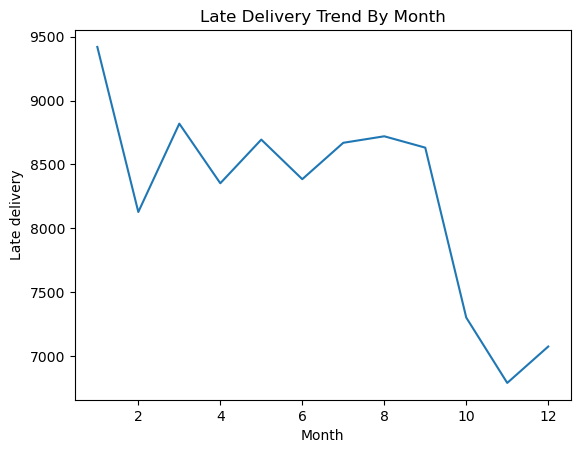

In [155]:
late_orders = supply[supply["Delivery Status"]=="Late delivery"]
monthly_counts= late_orders["Month"].value_counts().sort_index()
plt.plot(monthly_counts.index,monthly_counts.values)
plt.title("Late Delivery Trend By Month")
plt.xlabel("Month")
plt.ylabel("Late delivery")
plt.show()

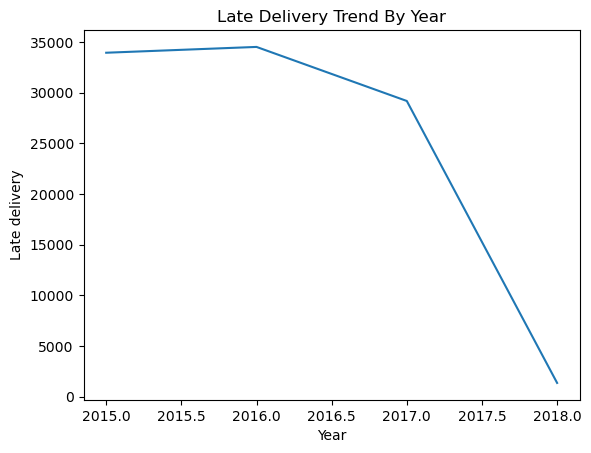

In [156]:
late_orders = supply[supply["Delivery Status"]=="Late delivery"]
yearly_counts= late_orders["Year"].value_counts().sort_index()
plt.plot(yearly_counts.index,yearly_counts.values)
plt.title("Late Delivery Trend By Year")
plt.xlabel("Year")
plt.ylabel("Late delivery")
plt.show()

**Finding:** 2015 and 2016 were the worst years for late deliveries. 
January consistently shows the highest monthly late delivery count. 
The sharp drop in 2018 reflects incomplete data, not improved performance.

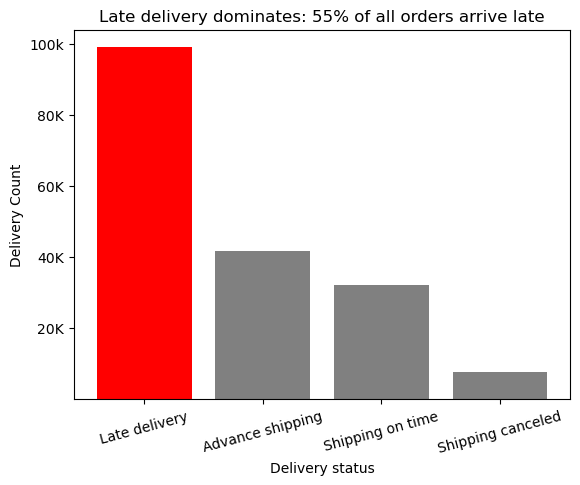

In [157]:
total_delivery = supply["Delivery Status"].value_counts()
colors=["red", "grey", "grey", "grey"]
plt.bar(total_delivery.index,total_delivery.values, color=colors)
plt.title("Late delivery dominates: 55% of all orders arrive late")
plt.xlabel("Delivery status")
plt.ylabel("Delivery Count")
plt.xticks(rotation=15)
plt.yticks([20000,40000,60000,80000,100000],["20K","40K","60K","80K","100k"])
plt.show()

**Finding:** Late delivery is the most common outcome, accounting for 55% of all orders. 
Only 18% of orders ship on time, signalling a systemic logistics problem.

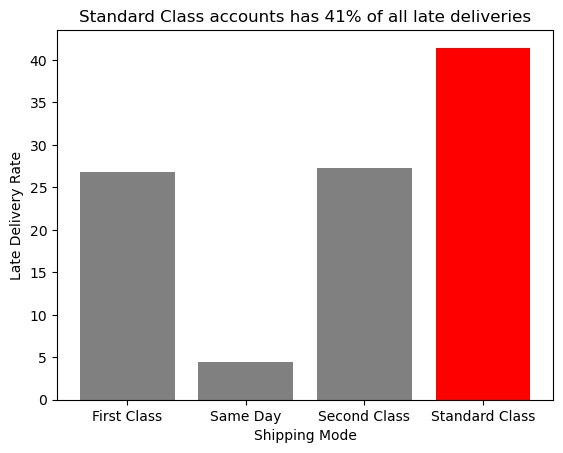

In [158]:
late_orders = supply[supply["Delivery Status"]=="Late delivery"]
Late_delivery_rate= late_orders["Shipping Mode"].value_counts(normalize=True).sort_index()*100
colors=["grey", "grey", "grey", "red"]
plt.bar(Late_delivery_rate.index,Late_delivery_rate.values, color=colors)
plt.title("Standard Class accounts has 41% of all late deliveries")
plt.xlabel("Shipping Mode")
plt.ylabel("Late Delivery Rate")
plt.show()

**Finding:** Standard Class shipping accounts for 41% of all late deliveries and 
has the highest late delivery volume of any shipping mode.

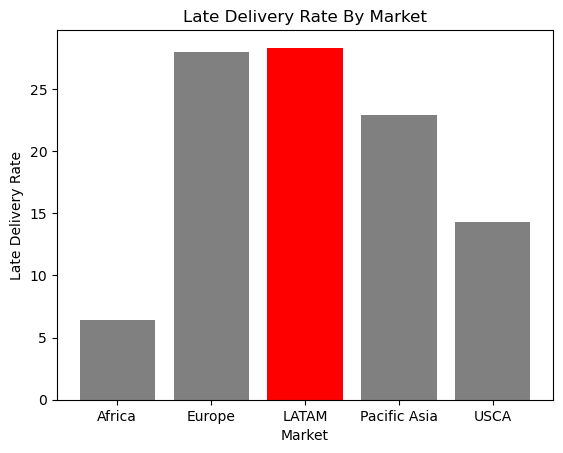

In [159]:
late_orders = supply[supply["Delivery Status"]=="Late delivery"]
Late_delivery_rate= late_orders["Market"].value_counts(normalize=True).sort_index()*100
colors=["grey", "grey", "red", "grey","gray"]
plt.bar(Late_delivery_rate.index,Late_delivery_rate.values, color=colors)
plt.title("Late Delivery Rate By Market")
plt.xlabel("Market")
plt.ylabel("Late Delivery Rate")
plt.show()

**Finding:** LATAM leads all markets with 28.33% of late deliveries. 
Africa performs best with only 6.5% of late orders.

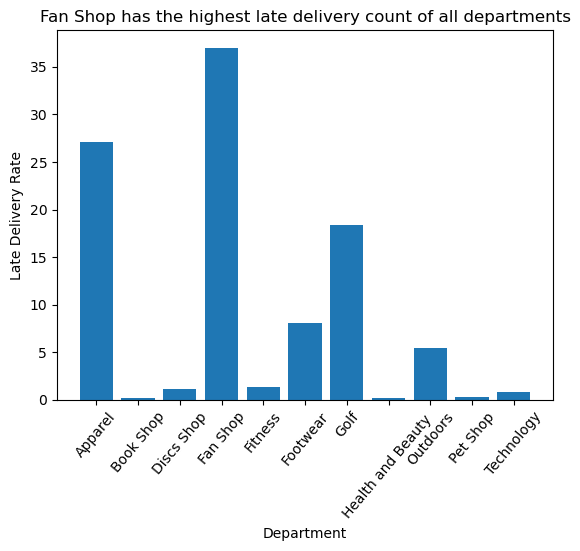

In [160]:
late_orders = supply[supply["Delivery Status"]=="Late delivery"]
Late_delivery_rate= late_orders["Department Name"].value_counts(normalize=True).sort_index()*100
plt.bar(Late_delivery_rate.index,Late_delivery_rate.values)
plt.title("Fan Shop has the highest late delivery count of all departments")
plt.xlabel("Department")
plt.ylabel("Late Delivery Rate")
plt.xticks(rotation=50)
plt.show()

**Finding:** Fan Shop accounts for 36,623 late deliveries — the highest of any department, 
representing over a third of all late orders.

## Summary of Key Findings

| Finding | Value |
|---|---|
| Late delivery rate | 55% of all orders |
| Worst shipping mode | Standard Class (41% of late orders) |
| Worst market | LATAM (28.33%) |
| Worst region | Central America (15.68%) |
| Worst department | Fan Shop (36,623 late orders) |
| Peak year | 2015–2016 |
| Worst month | January |